In [1]:
import os
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
from matplotlib import gridspec

from IPython.display import Markdown as md

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
bw = 5.0

In [3]:
file_name = (f'../data/data=waiting-bw={bw}-kernel=gaussian_poly2-empirical-inf-fun-' + 
             'summary-baseden=Gamma-36-2-gridpoints=1-202-different-gaps.xlsx')

df = pd.read_excel(file_name, sheet_name = 'different-gaps')
df_gap = df[df.gap != 'data']
df_data = df[df.gap == 'data']
df_gap.gap = df_gap.gap.astype(str).astype("category")
df_data.gap = df_data.gap.astype(str).astype("category")

In [4]:
gap_list = ['8', '4', '2', '1', '0.5']
cat_type = CategoricalDtype(categories = gap_list, ordered = True)
log_lambda_list = np.arange(-15., -5., 1).tolist()

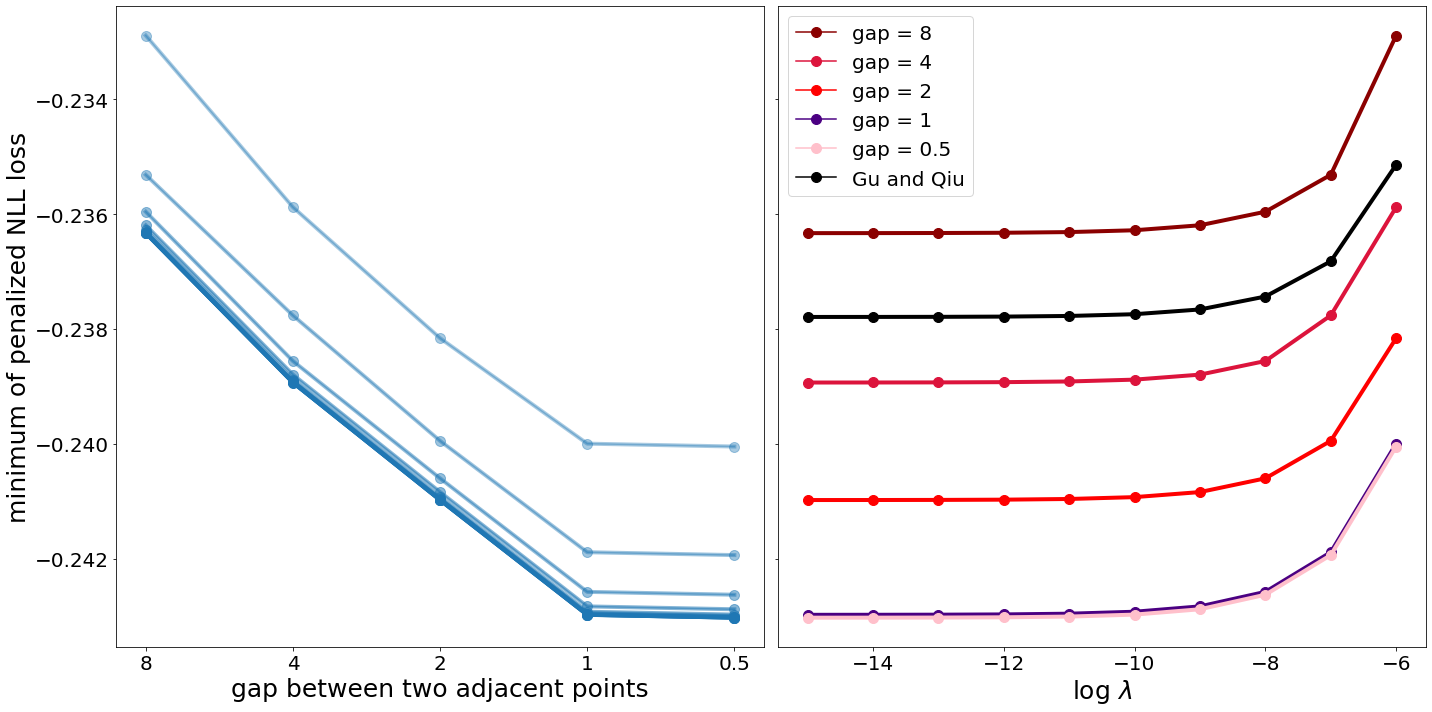

In [6]:
fig = plt.figure(constrained_layout=False)

fig.set_figheight(10)
fig.set_figwidth(20)
ncols = 2
nrows = 1
linewidth = 4.0

color = 'tab:blue'

label_fontsize = 25
tick_fontsize = 20
info_fontsize = 20

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)

# ------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(spec[0, 0])

alpha = 1.0
alpha_factor = 0.9

for log_lambda in log_lambda_list: 
    
    subdf = df_gap[df_gap.log_lambda == log_lambda]
    
    ax1.plot(subdf.gap, subdf.loss, linestyle = 'solid', linewidth = linewidth, color = color, 
            alpha = alpha)
    ax1.plot(subdf.gap, subdf.loss, marker = 'o', markersize = 10, color = color, alpha = alpha)
    alpha = alpha * alpha_factor
    
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
ax1.set_xlabel('gap between two adjacent points', fontsize = label_fontsize)
ax1.set_ylabel(r'minimum of penalized NLL loss', fontsize = label_fontsize)

# ------------------------------------------------------------------------------------------
color1 = 'darkred'
color2 = 'crimson'
color3 = 'red'
color4 = 'indigo'
color5 = 'pink'


ax = fig.add_subplot(spec[0, 1], sharey=ax1)
plt.setp(ax.get_yticklabels(), visible=False)
subdf1 = df_gap[df_gap.log_lambda.isin(log_lambda_list)]
subdf2 = df_data[df_data.log_lambda.isin(log_lambda_list)]

i = 1
for gap in gap_list: 
    
    sub = subdf1[subdf1.gap == gap]
    
    ax.plot(sub.log_lambda, sub.loss, linestyle = 'solid', linewidth = linewidth, 
            color = eval(f'color{i}'))
    ax.plot(sub.log_lambda, sub.loss, marker = 'o', markersize = 10, color = eval(f'color{i}'), 
            label = f'gap = {gap_list[i-1]}')
    i += 1

ax.plot(subdf2.log_lambda, subdf2.loss, linestyle = 'solid', linewidth = linewidth, color = 'k')
ax.plot(subdf2.log_lambda, subdf2.loss, marker = 'o', markersize = 10, color = 'k', label = 'Gu and Qiu')
   
ax.legend(fontsize = tick_fontsize)
ax.tick_params(axis = 'x', labelsize = tick_fontsize)
ax.set_xlabel(r'$\log \ \lambda$', fontsize = label_fontsize)
# ax.set_ylabel(r'value of penalized NLL loss', fontsize = label_fontsize)

plt.tight_layout()

plt.savefig(f'../plots/choose-best-fin-dim-approx-subspace-bw={bw}.pdf')